# Importing

In [1]:
# %% Cell 1: Imports
import pandas as pd
import numpy as np
from darts import TimeSeries
from darts.models import ARIMA, LinearRegressionModel, RandomForest, XGBModel

seed = 24775456

import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
import pyarrow as pa
import datetime as dt

# Load Data 

In [2]:
# %% Cell 2: Load Data
def loadData():
    df = pd.read_parquet("gafanha.parquet")
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.round("h")
    print(df.count())
    return (
        df.pivot_table(index="timestamp", columns="collection", values="value", aggfunc="median")
        .asfreq("h")
        .loc[:"2024-12-31 23:00"]
        .reset_index()
    )

df = loadData()




# %% Cell 3: Readings per day per variable - for validating the dataset only
def checkDailyCount(df):
    df_daily_counts = df.set_index("timestamp").resample("D").count()

    # quick visual: counts per year for each variable
    df_daily_counts.groupby(df_daily_counts.index.year).mean().plot(
        kind="bar", figsize=(12, 5), title="Avg daily reading count per variable, by year"
    )
    plt.ylabel("avg readings/day")
    plt.tight_layout()
    plt.show()

station       916774
timestamp     916774
collection    916774
value         916774
unit          916774
source_db     916774
date          916774
values        916774
dtype: int64


In [3]:
# %% Cell 4: Force daily, median and fill in missing values with darts package
from darts.utils.missing_values import fill_missing_values
daily = df.set_index("timestamp").resample("D").median()
daily = daily.asfreq("D")

print(daily.count())


# Set up the AQI bins for each pollutant based on the standard AQI breakpoints (European standards)
aqi_bins = {
    "PM25": [-np.inf, 10, 20, 25, 50, np.inf],
    "PM10": [-np.inf, 20, 35, 50, 100, np.inf],
    "NO2":  [-np.inf, 40, 100, 200, 400, np.inf],
    "O3":   [-np.inf, 80, 120, 180, 240, np.inf],
    "SO2":  [-np.inf, 100, 200, 350, 500, np.inf],
}
sub_idx = pd.concat(
    [pd.cut(daily[p], bins=b, labels=[1, 2, 3, 4, 5]).astype(float) for p, b in aqi_bins.items()],
    axis=1,
)
daily["AQI"] = sub_idx.max(axis=1, skipna=True)
dominant = sub_idx.dropna(how="all").idxmax(axis=1)
last_valid = daily["AQI"].last_valid_index() 
print(last_valid)

# interpolates NaNs values
daily.index = daily.index.tz_localize(None)
series = TimeSeries.from_dataframe(daily, freq="D")
series = fill_missing_values(series)

collection
Benzene          2963
CO               3010
NO               2979
NO2              2979
NOx              2979
O3               3008
PM10             2632
PM25             2626
Particles        2626
Precipitation     366
Radiation         366
SO2              2990
Temperature      2635
WindDirection    3001
WindSpeed        3001
dtype: int64
2024-12-31 00:00:00+00:00


In [4]:
print(sub_idx.notna().groupby(sub_idx.index.year).mean())
dominant.groupby(dominant.index.year).value_counts(normalize=True).unstack()

               PM25      PM10       NO2        O3       SO2
timestamp                                                  
2016       1.000000  1.000000  1.000000  1.000000  1.000000
2017       1.000000  1.000000  0.997260  1.000000  1.000000
2018       0.835616  0.835616  0.819178  0.835616  0.832877
2019       1.000000  1.000000  0.994521  0.989041  0.975342
2020       0.972678  0.991803  0.948087  0.991803  0.991803
2021       0.980822  0.978082  1.000000  1.000000  1.000000
2022       1.000000  1.000000  0.994521  1.000000  0.986301
2023       0.983562  0.983562  0.983562  1.000000  0.986301
2024       0.000000  0.000000  1.000000  1.000000  0.994536


,NO2,O3,PM10,PM25
timestamp,,,,
2016,NaN,0.013072,0.346405,0.640523
2017,NaN,0.027397,0.405479,0.567123
2018,NaN,0.026230,0.767213,0.206557
2019,NaN,0.021918,0.536986,0.441096
2020,NaN,0.071429,0.109890,0.818681
2021,0.019178,0.082192,0.082192,0.816438
2022,NaN,0.032877,0.060274,0.906849
2023,0.005479,0.095890,0.041096,0.857534
2024,0.770492,0.229508,NaN,NaN


# Set up and prepare for training 3 ARIMA Models

In [5]:
# %% Cell 5: Set targets and covariates
'''
    ARIMA takes future_covariates: shift 1 day = same info as past_covariates, no same-day leak
    This is because ARIMA uses the past values of the target variable to predict future values, and if we include same-day covariates, 
    it would introduce information from the future into the model, leading to data leakage. 
    By shifting the covariates by one day, only past information is used for prediction, maintaining the integrity of the model.
'''

covariates = series.drop_columns(["AQI", "Radiation", "Precipitation"]).shift(1)
target = series["AQI"].slice_intersect(covariates)
covariates = covariates.slice_intersect(target)
assert not covariates.to_dataframe().isna().any().any()

In [6]:
# %% Cell 6: generic per-period pipeline
import optuna
from darts.metrics import rmse, mae, mape

def run_period(target, covariates, model_cls, param_space, fixed_param, n_trials=500, params=None, cov="past_covariates"):

    y_train, y_temp = target.split_before(0.6)
    y_val, y_test = y_temp.split_before(0.5)
    x_train, x_temp = covariates.split_before(0.6)
    x_val, x_test = x_temp.split_before(0.5)

    # If no Parameters are provided, perform hyperparameter optimisation using Optuna
    if params is None:
        def findParam(trial):
            p = {name: fn(trial) for name, fn in param_space.items()}
            model = model_cls(**p, **fixed_param)
            model.fit(y_train, **{cov: x_train})
            preds = model.historical_forecasts(
                series=y_train.append(y_val), **{cov: x_train.append(x_val)},
                start=y_val.start_time(), forecast_horizon=1, stride=1,
                retrain=False, last_points_only=True, verbose=False,
            ).map(lambda x: np.round(x))
            return rmse(y_val, preds), mae(y_val, preds), mape(y_val, preds)

        # Minimise all three metrics (RMSE, MAE, MAPE) simultaneously
        study = optuna.create_study(directions=["minimize"] * 3,
                                    sampler=optuna.samplers.TPESampler(seed=seed))
        # failed ARIMA fits (non-stationary, singular) = skipped trial
        study.optimize(findParam, n_trials=n_trials, show_progress_bar=True,
                       catch=(ValueError, np.linalg.LinAlgError))

        vals = np.array([t.values for t in study.best_trials])
        best = study.best_trials[np.argmin((vals / vals.min(axis=0)).sum(axis=1))]
        params = best.params

    y_fit, x_fit = y_train.append(y_val), x_train.append(x_val)
    test_pred = model_cls(**params, **fixed_param).historical_forecasts(
        series=y_fit.append(y_test), **{cov: x_fit.append(x_test)},
        start=y_test.start_time(), forecast_horizon=1, stride=1,
        retrain=True, train_length=None, last_points_only=True, verbose=False,
    ).map(lambda x: np.round(x))

    model = model_cls(**params, **fixed_param).fit(y_fit, **{cov: x_fit})

    return dict(
        model=model, params=params, y=target, x=covariates, y_test=y_test, x_test=x_test, test_pred=test_pred,
        model_metrics=(rmse(y_test, test_pred), mae(y_test, test_pred), mape(y_test, test_pred)),
        sizes=(len(y_train), len(y_val), len(y_test)),
    )

# For Each of the Periods

### Config the models - run search

In [7]:
# %% Cell 7: ARIMA config
import joblib, warnings
warnings.filterwarnings("ignore")   

arima_fixed = {}
arima_space = dict(
    p=lambda t: t.suggest_int("p", 0, 7),
    d=lambda t: t.suggest_int("d", 0, 1),
    q=lambda t: t.suggest_int("q", 0, 3),
)

# 3 periods: pre, during, post
bounds = {"pre":    (None, "2020-02-29"),
          "during": ("2020-03-01", "2021-04-30"),
          "post":   ("2021-05-01", None)}

### Refit and recreate result (Train cell)

In [8]:
results = {}
for name, (s, e) in bounds.items():
    lo = pd.Timestamp(s) if s else target.start_time()
    hi = pd.Timestamp(e) if e else target.end_time()
    results[name] = run_period(target.slice(lo, hi), covariates.slice(lo, hi), ARIMA,
                               arima_space, arima_fixed, n_trials=500, cov="future_covariates")
    r = results[name]
    print(name, r["sizes"], "model", r["model_metrics"])
    r["model"].save(f"arima_aqi_{name}.pkl")
joblib.dump(results, "results_arima.pkl")

[I 2026-10-01 00:16:51,010] A new study created in memory with name: no-name-18c2d35e-bee9-4d13-8c66-fe8092455bd4


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-10-01 00:16:53,458] Trial 0 finished with values: [0.8709883407113854, 0.5977011494252874, 25.881226053639846] and parameters: {'p': 5, 'd': 0, 'q': 0}.
[I 2026-10-01 00:16:55,428] Trial 1 finished with values: [0.8862508747678729, 0.6168582375478927, 26.545338441890166] and parameters: {'p': 0, 'd': 0, 'q': 3}.
[I 2026-10-01 00:16:57,057] Trial 2 finished with values: [0.8840866447369844, 0.6206896551724138, 26.8007662835249] and parameters: {'p': 0, 'd': 0, 'q': 2}.
[I 2026-10-01 00:16:59,699] Trial 3 finished with values: [0.8621455904643299, 0.5900383141762452, 25.85568326947637] and parameters: {'p': 1, 'd': 1, 'q': 3}.
[I 2026-10-01 00:17:02,128] Trial 4 finished with values: [0.8969937018449045, 0.6283524904214559, 26.896551724137932] and parameters: {'p': 3, 'd': 0, 'q': 1}.
[I 2026-10-01 00:17:04,816] Trial 5 finished with values: [0.8621455904643299, 0.5900383141762452, 25.85568326947637] and parameters: {'p': 1, 'd': 1, 'q': 3}.
[I 2026-10-01 00:17:08,044] Trial 6 fi

[I 2026-10-01 00:43:13,004] A new study created in memory with name: no-name-5cb44280-e7ff-4562-8d1f-40e1ad84fa36


pre (783, 261, 263) model (np.float64(0.8978216137909101), np.float64(0.6159695817490495), np.float64(37.30038022813688))


...

[I 2026-10-01 00:48:48,398] A new study created in memory with name: no-name-8c70d2c8-4142-4e22-8ba0-4112b3fef063


during (255, 85, 86) model (np.float64(0.9086150974691304), np.float64(0.6162790697674418), np.float64(33.31395348837209))


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-10-01 00:48:50,663] Trial 0 finished with values: [0.7201782532247905, 0.503731343283582, 45.08706467661691] and parameters: {'p': 5, 'd': 0, 'q': 0}.
[I 2026-10-01 00:48:52,701] Trial 1 finished with values: [0.7071067811865476, 0.48507462686567165, 43.59452736318408] and parameters: {'p': 0, 'd': 0, 'q': 3}.
[I 2026-10-01 00:48:54,880] Trial 2 finished with values: [0.7175830078355593, 0.5, 44.90049751243781] and parameters: {'p': 0, 'd': 0, 'q': 2}.
[I 2026-10-01 00:48:57,612] Trial 3 finished with values: [0.6047078979069521, 0.35074626865671643, 25.932835820895523] and parameters: {'p': 1, 'd': 1, 'q': 3}.
[I 2026-10-01 00:48:59,955] Trial 4 finished with values: [0.7018100265975371, 0.47761194029850745, 42.848258706467654] and parameters: {'p': 3, 'd': 0, 'q': 1}.
[I 2026-10-01 00:49:02,636] Trial 5 finished with values: [0.6047078979069521, 0.35074626865671643, 25.932835820895523] and parameters: {'p': 1, 'd': 1, 'q': 3}.
[I 2026-10-01 00:49:05,985] Trial 6 finished with

['results_arima.pkl']

### Build the results - run once after training and analysaing the 1st time (after the graphs are done)

In [21]:
pp = pd.read_csv("report_params_arima.csv", index_col=0).astype(int).to_dict("index")

results = {}
for name, (s, e) in bounds.items():
    lo = pd.Timestamp(s) if s else target.start_time()
    hi = pd.Timestamp(e) if e else target.end_time()
    results[name] = run_period(target.slice(lo, hi), covariates.slice(lo, hi), ARIMA,
                               None, arima_fixed, params=pp[name], cov="future_covariates")
    print(name, results[name]["model_metrics"])
joblib.dump(results, "results_arima.pkl")

pre (np.float64(0.8978216137909101), np.float64(0.6159695817490495), np.float64(37.30038022813688))
during (np.float64(0.9086150974691304), np.float64(0.6162790697674418), np.float64(33.31395348837209))
post (np.float64(0.40443636487610846), np.float64(0.15613382899628253), np.float64(12.267657992565056))


['results_arima.pkl']

# Cross Validation between models

### Load the models

In [8]:
results = joblib.load("results_arima.pkl")

In [9]:
# %% Cell 8: cross-evaluation
def score(model, y_w):
    end = y_w.end_time()
    p = model.historical_forecasts(
        series=target.slice(target.start_time(), end),
        future_covariates=covariates.slice(covariates.start_time(), end),
        start=y_w.start_time(), forecast_horizon=1, stride=1,
        retrain=False, last_points_only=True, verbose=False,
    ).map(lambda x: np.round(x))
    return rmse(y_w, p), mae(y_w, p)

cross = pd.DataFrame(
    {test: {f"{m}-model": score(results[m]["model"], results[test]["y_test"])[0]
            for m in results}
     for test in results}
).round(3)
cross.index.name, cross.columns.name = "model", "test window (RMSE)"
print(cross)

test window (RMSE)    pre  during   post
model                                   
pre-model           0.889   0.863  0.427
during-model        0.883   0.835  0.404
post-model          0.883   0.800  0.418


# Report, SHAP and other analysis visualisation

In [10]:
# %% Cell 9: report
report = pd.DataFrame([
    dict(period=name, model="arima", rmse=r["model_metrics"][0], mae=r["model_metrics"][1],
         mape=r["model_metrics"][2], **dict(zip(("train", "val", "test"), r["sizes"])))
    for name, r in results.items()
])
params = pd.DataFrame({name: r["params"] for name, r in results.items()}).T

print(report.round(3).to_string(index=False))
print(params)
report.to_csv("report_metrics_arima.csv", index=False)
params.to_csv("report_params_arima.csv")

period model  rmse   mae   mape  train  val  test
   pre arima 0.898 0.616 37.300    783  261   263
during arima 0.909 0.616 33.314    255   85    86
  post arima 0.404 0.156 12.268    804  268   269
        p  d  q
pre     4  1  1
during  2  1  2
post    1  1  2


### Driver Importance

['Benzene', 'CO', 'NO', 'NO2', 'NOx', 'O3', 'PM10', 'PM25', 'Particles', 'SO2', 'Temperature', 'WindDirection', 'WindSpeed']


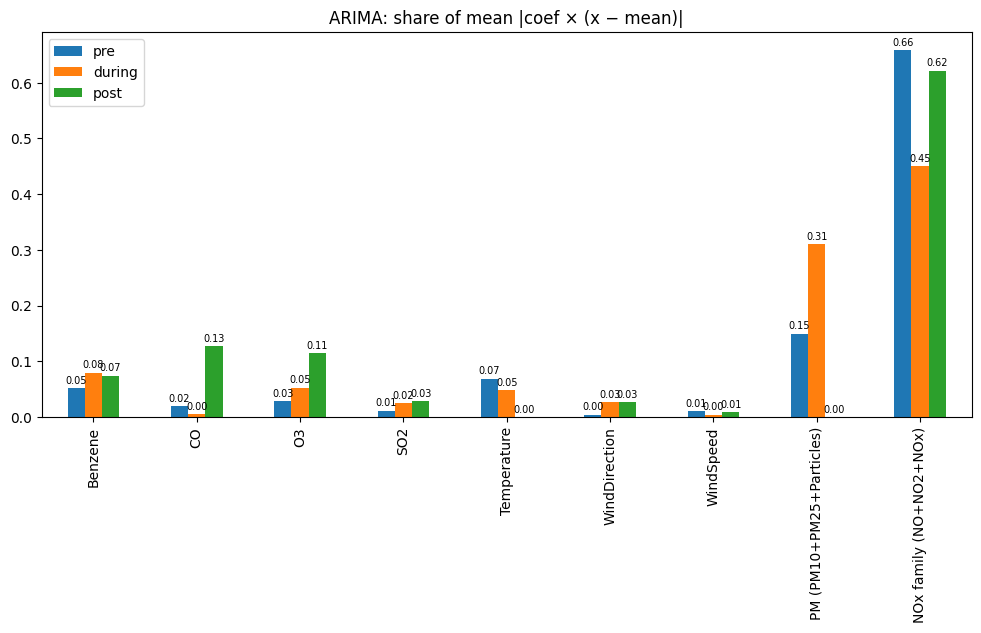

In [11]:
# %% Cell 10: driver importance per period (linear: coef * (x - mean) = exact SHAP)
warnings.filterwarnings("ignore")

def var_importance_on(model, y_w):
    X = covariates.slice(y_w.start_time(), y_w.end_time()).to_dataframe()
    m = model.model
    b = pd.Series(m.params, m.param_names).filter(regex=r"^x\d+$")   # exog order = covariate order
    b.index = X.columns
    return (X - X.mean()).mul(b).abs().mean()

groups = {"PM (PM10+PM25+Particles)": ["PM10", "PM25", "Particles"],
          "NOx family (NO+NO2+NOx)": ["NO", "NO2", "NOx"]}

def grouped(imp):
    g = imp.copy()
    for name, cols in groups.items():
        g.loc[name] = g.loc[cols].sum()
        g = g.drop(cols)
    return g / g.sum()

imp = pd.DataFrame({name: var_importance_on(r["model"], r["y_test"]) for name, r in results.items()})
print(imp.index.tolist())

ax = grouped(imp).plot.bar(figsize=(12, 5), title="ARIMA: share of mean |coef × (x − mean)|")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()

### Tested variable impacts of 3 models in same period

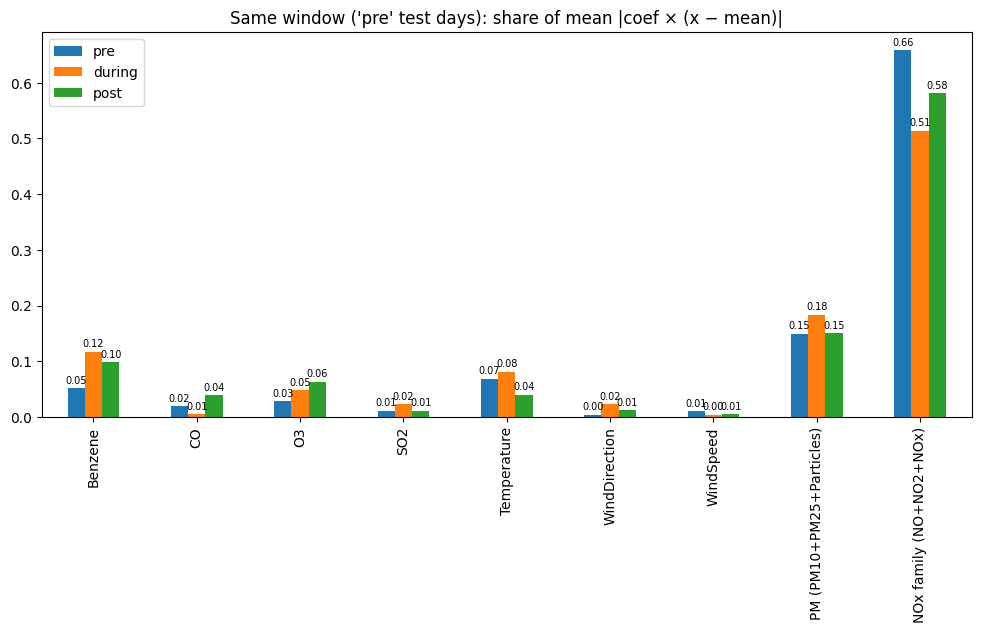

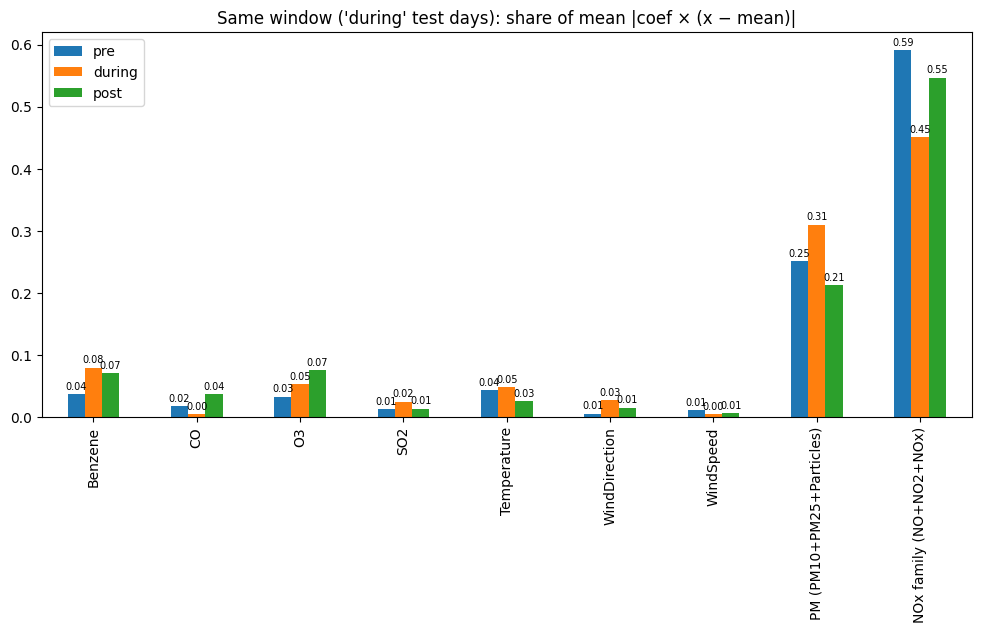

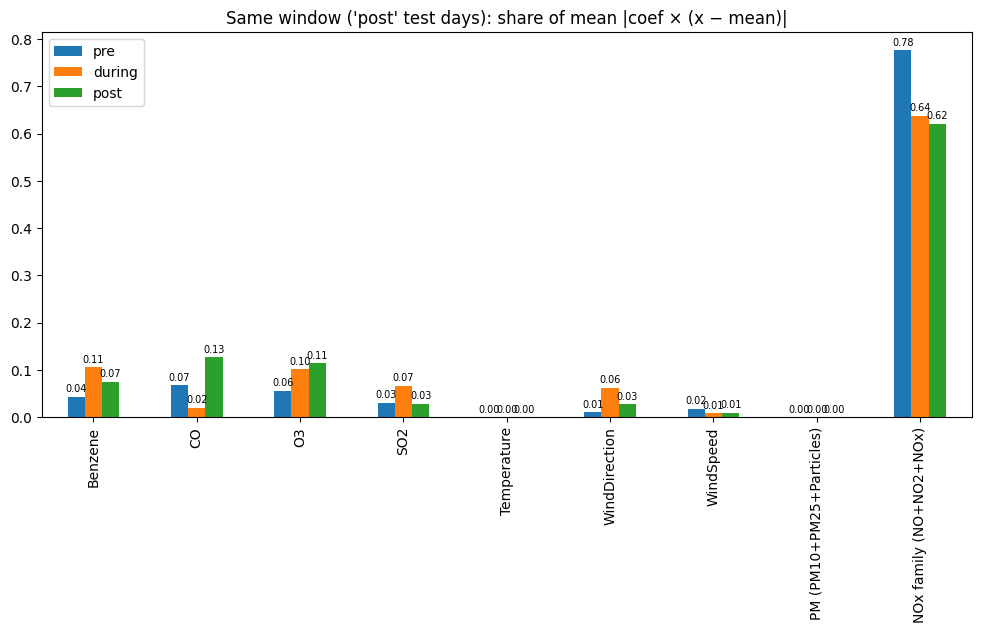

In [12]:
# %% Cell 11: all 3 models on the same window
for w, rw in results.items():
    same = pd.DataFrame({m: var_importance_on(r["model"], rw["y_test"]) for m, r in results.items()})
    ax = grouped(same).plot.bar(figsize=(12, 5),
        title=f"Same window ('{w}' test days): share of mean |coef × (x − mean)|")
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
    plt.show()

### Quick check for 1 week and 1 month performance

These 2 performance has lower accuracy due to the compounding error as the model uses the previous day prediction to predict the following day, bringing the error from that previpous day forward

In [22]:
raw_cov = series.drop_columns(["AQI", "Radiation", "Precipitation"])

def horizon_scores(h):
    cov = raw_cov.shift(h)
    tgt = series["AQI"].slice_intersect(cov)
    cov = cov.slice_intersect(tgt)
    out = {}
    for name, (s, e) in bounds.items():
        lo = pd.Timestamp(s) if s else tgt.start_time()
        hi = pd.Timestamp(e) if e else tgt.end_time()
        y, x = tgt.slice(lo, hi), cov.slice(lo, hi)
        y_fit, y_test = y.split_before(0.8)
        x_fit, _ = x.split_before(0.8)
        m = ARIMA(**results[name]["params"]).fit(y_fit, future_covariates=x_fit)
        p = m.historical_forecasts(series=y, future_covariates=x, start=y_test.start_time(),
                                   forecast_horizon=h, stride=1, retrain=False,
                                    last_points_only=True, verbose=False).map(lambda x: np.round(x))
        # For naive (add in for testing only)
        # nv = tgt.shift(h).slice_intersect(p)
        # p = p.slice_intersect(nv)
        yt = y_test.slice_intersect(p)
        out[name] = dict(arima=rmse(yt, p))
    return pd.DataFrame(out).T

print(pd.concat({f"{h}d": horizon_scores(h) for h in (1, 7, 30)}, axis=1).round(3))

           1d     7d    30d
        arima  arima  arima
pre     0.889  1.150  1.400
during  0.835  1.031  0.908
post    0.418  0.390  0.474


### Line graph for models' prediction vs actual data

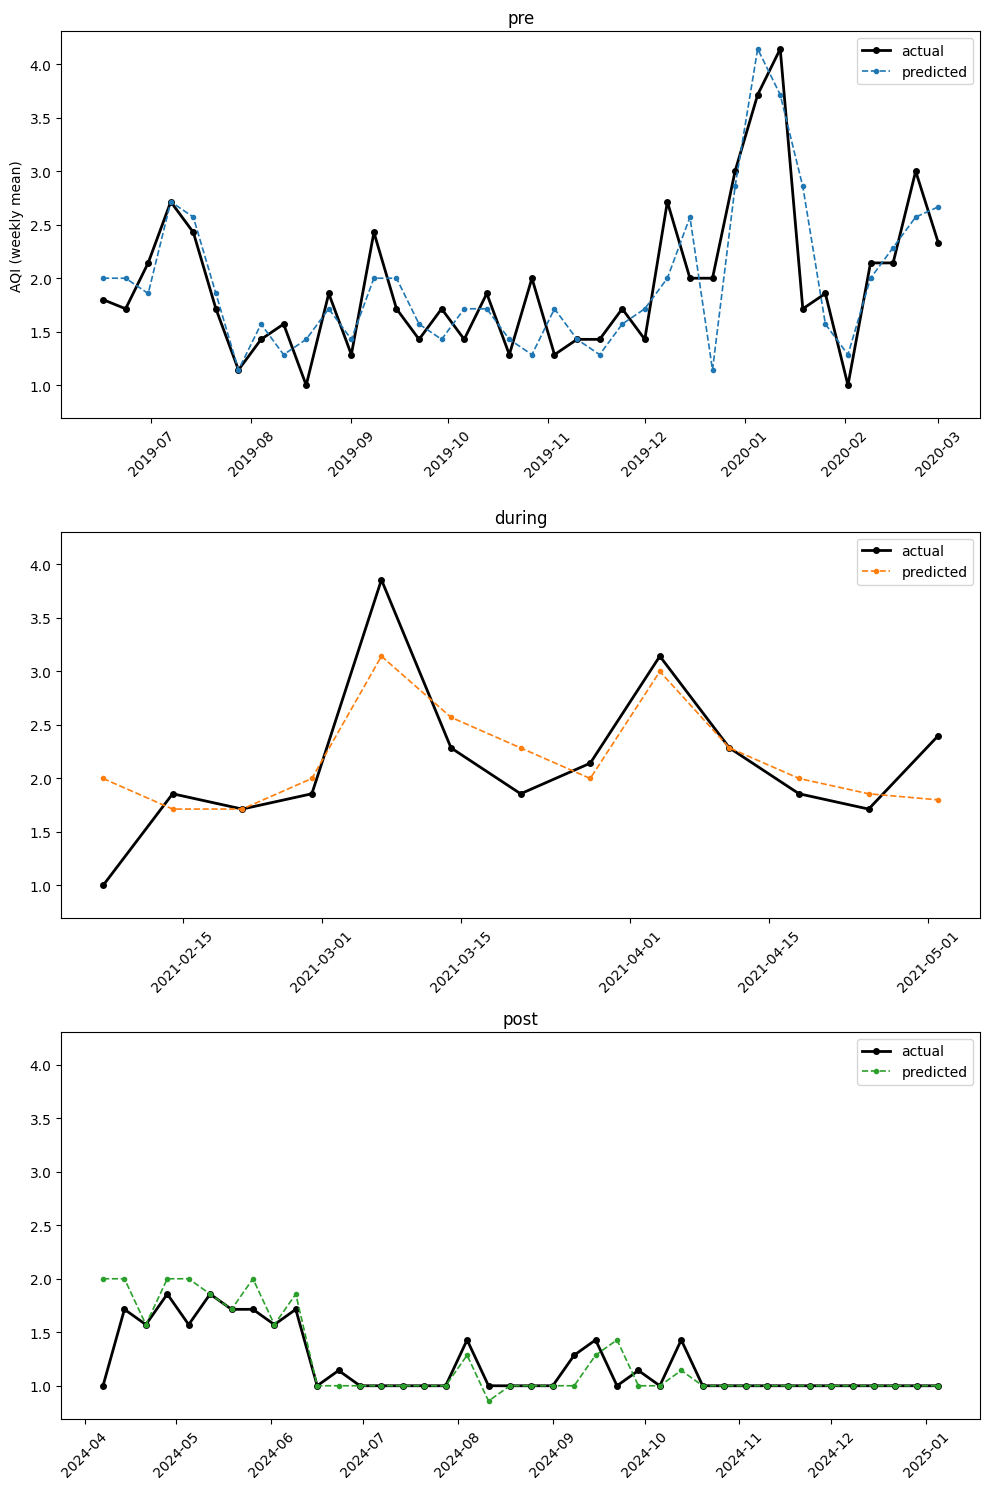

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharey=True)
colors = dict(pre="tab:blue", during="tab:orange", post="tab:green")

for ax, (name, r) in zip(axes, results.items()):
    actual_w = r["y_test"].to_series().resample("W").mean()
    pred_w = r["test_pred"].to_series().resample("W").mean()

    ax.plot(actual_w.index, actual_w.values, color="black", lw=2, marker="o", markersize=4, label="actual", zorder=2)
    ax.plot(pred_w.index, pred_w.values, color=colors[name], lw=1.2, marker="o", markersize=3,
        linestyle="--", label="predicted", zorder=3)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

    

axes[0].set_ylabel("AQI (weekly mean)")
plt.tight_layout()
plt.show()

### What pollutant dominates each periods?

<Axes: title={'center': 'Dominant pollutant share of days'}>

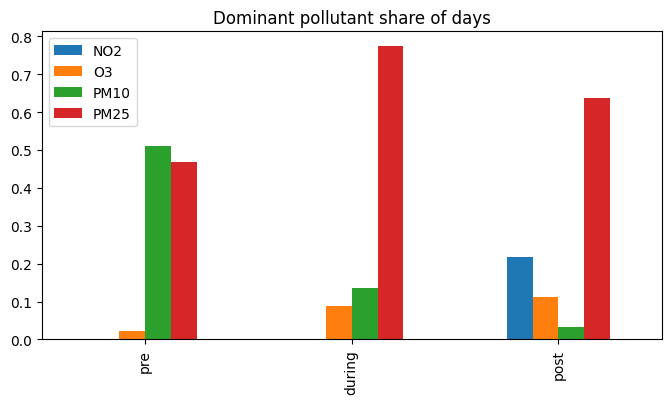

In [14]:
idx = dominant.index.tz_localize(None)
per = np.where(idx <= "2020-02-29", "pre", np.where(idx <= "2021-04-30", "during", "post"))
(dominant.groupby(per).value_counts(normalize=True).unstack()
    .loc[["pre", "during", "post"]].plot.bar(figsize=(8, 4), title="Dominant pollutant share of days"))

### Correlation between each covariate in 3 periods

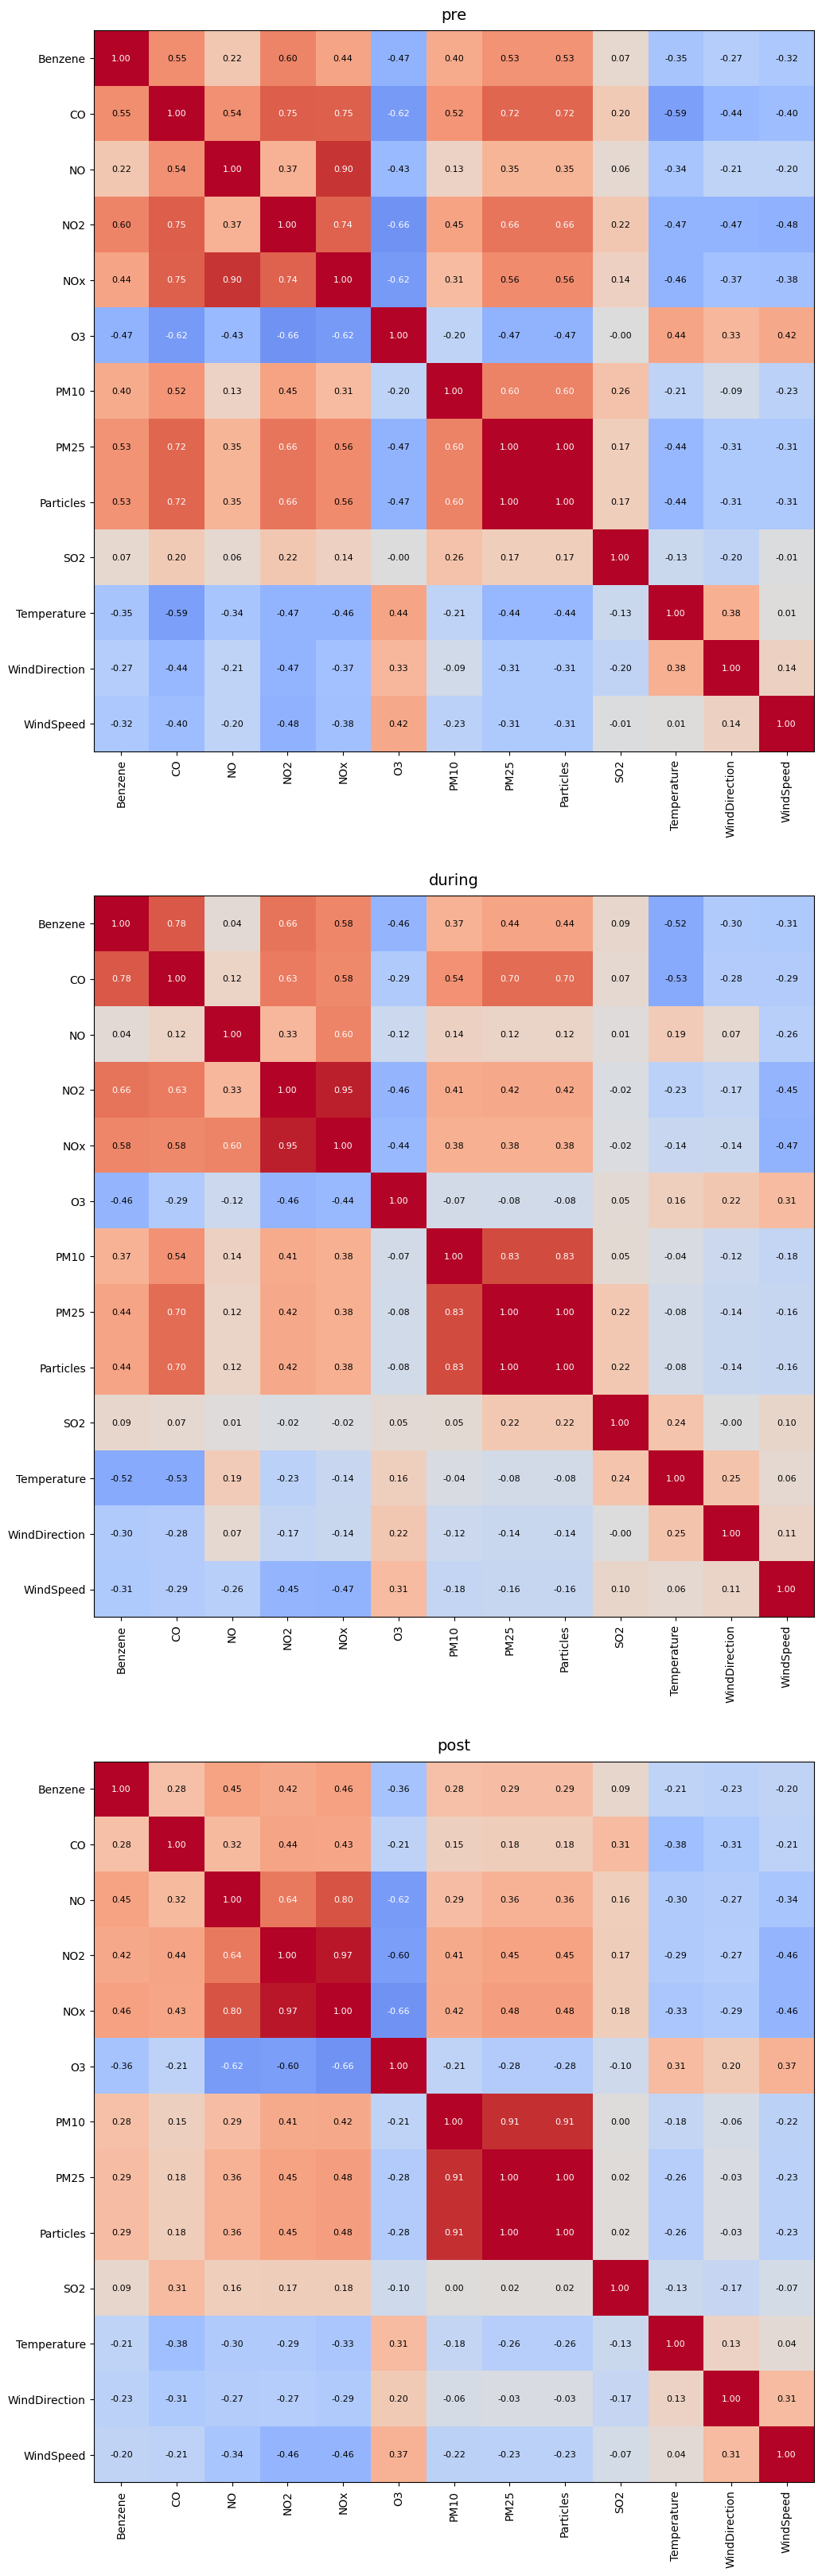

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(80, 40))

for ax, (n, (s, e)) in zip(axes, bounds.items()):
    c = covariates.slice(
        pd.Timestamp(s) if s else covariates.start_time(),
        pd.Timestamp(e) if e else covariates.end_time()
    ).to_dataframe().corr()
    
    im = ax.imshow(c, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(n, fontsize=14, pad=10)
    
    ax.set_xticks(range(len(c)))
    ax.set_xticklabels(c.columns, rotation=90)
    ax.set_yticks(range(len(c)))
    ax.set_yticklabels(c.columns)
    
    # Add numerical values to each heatmap cell
    for i in range(len(c)):
        for j in range(len(c)):
            val = c.iloc[i, j]
            # Change text color to white for dark backgrounds for contrast
            text_color = "white" if abs(val) > 0.6 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=8)

# Increase vertical spacing (padding) between subplots
plt.subplots_adjust(hspace=0.2)

plt.show()